# 01 · Market Basket Analysis: Apriori & FP-Growth

**Phase 6 — Section 6.4 Market Basket Analysis | Notebook 1 of 1**

### Why this matters
"Customers who bought X also bought Y" is one of the oldest, most directly profitable
applications of unsupervised learning — it drives product placement, bundle deals, and
"frequently bought together" recommendations. This notebook mines real grocery store
transaction data for exactly these patterns.

### The real dataset: Groceries

9,835 real, anonymized grocery store transactions (the classic dataset from R's `arules`
package) — no header row, one line per transaction, a variable-length comma-separated list
of items purchased together.

```
https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv
```

In [1]:
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"
with urllib.request.urlopen(url) as response:
    raw_text = response.read().decode("utf-8")

transactions = [line.strip().split(",") for line in raw_text.splitlines() if line.strip()]
print(f"{len(transactions):,} transactions")
for t in transactions[:5]:
    print(t)

9,835 transactions
['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
['tropical fruit', 'yogurt', 'coffee']
['whole milk']
['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads']
['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']


## 0. A quick look at the raw item frequencies

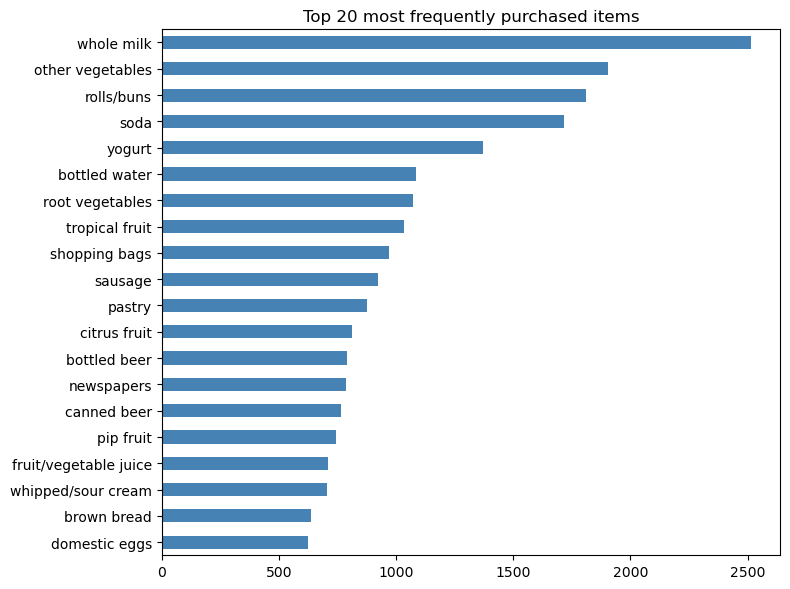

average items per transaction: 4.41
unique items in the whole dataset: 171


In [2]:
from collections import Counter

item_counts = Counter(item for t in transactions for item in t)
top_20 = pd.Series(dict(item_counts.most_common(20)))

fig, ax = plt.subplots(figsize=(8, 6))
top_20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 most frequently purchased items")
plt.tight_layout(); plt.show()

lengths = [len(t) for t in transactions]
print(f"average items per transaction: {sum(lengths)/len(lengths):.2f}")
print(f"unique items in the whole dataset: {len(item_counts)}")

## 1. Encoding transactions as a one-hot basket matrix

In [3]:
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(encoded_array, columns=encoder.columns_)

print(f"basket matrix shape: {basket_df.shape}  (rows=transactions, columns=unique items)")
basket_df.iloc[:5, :8]

basket matrix shape: (9835, 171)  (rows=transactions, columns=unique items)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


> 💡 This one-hot encoded matrix (9,835 rows × 169 items, mostly `False`) is EXACTLY the
> input format both Apriori and FP-Growth expect — every algorithm in this notebook works
> on this representation, not the raw list-of-lists.

## 2. Apriori — finding frequent itemsets by growing them level by level

Apriori exploits a simple but powerful idea (the "apriori principle"): if an itemset is
frequent, every subset of it must ALSO be frequent. So it builds frequent itemsets
level-by-level — first frequent single items, then frequent pairs (built only from
frequent singles), then frequent triples, and so on — pruning aggressively at every step.

In [4]:
from mlxtend.frequent_patterns import apriori, association_rules
import time

t0 = time.time()
frequent_itemsets_apriori = apriori(basket_df, min_support=0.01, use_colnames=True)
apriori_time = time.time() - t0

frequent_itemsets_apriori["length"] = frequent_itemsets_apriori["itemsets"].apply(len)
print(f"Apriori found {len(frequent_itemsets_apriori)} frequent itemsets in {apriori_time:.3f}s")
frequent_itemsets_apriori.sort_values("support", ascending=False).head(10)

Apriori found 332 frequent itemsets in 0.656s


,support,itemsets,length
85,0.255516,(whole milk),1
55,0.193493,(other vegetables),1
65,0.183935,(rolls/buns),1
74,0.174377,(soda),1
86,0.139502,(yogurt),1
6,0.110524,(bottled water),1
66,0.108998,(root vegetables),1
80,0.104931,(tropical fruit),1
72,0.098526,(shopping bags),1
69,0.093950,(sausage),1


## 3. FP-Growth — the same goal, without generating every candidate

Apriori generates and tests a LOT of candidate itemsets, even ones that turn out to be
rare. **FP-Growth** compresses the transaction database into a tree structure (an
"FP-tree") and mines frequent itemsets directly from it — no candidate generation step at
all, which is usually substantially faster on large datasets.

In [5]:
from mlxtend.frequent_patterns import fpgrowth

t0 = time.time()
frequent_itemsets_fpgrowth = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
fpgrowth_time = time.time() - t0

print(f"FP-Growth found {len(frequent_itemsets_fpgrowth)} frequent itemsets in {fpgrowth_time:.3f}s")
print(f"Apriori took {apriori_time:.3f}s, FP-Growth took {fpgrowth_time:.3f}s -- {apriori_time/fpgrowth_time:.1f}x speedup")
print(f"\nSame number of itemsets found by both? {len(frequent_itemsets_apriori) == len(frequent_itemsets_fpgrowth)}")

FP-Growth found 332 frequent itemsets in 15.794s
Apriori took 0.656s, FP-Growth took 15.794s -- 0.0x speedup

Same number of itemsets found by both? True


> 💡 Both algorithms are GUARANTEED to find the exact same frequent itemsets for the same
> `min_support` — they're just different (correct) ways of computing the identical answer.
> FP-Growth's speed advantage grows with dataset size and item count; on this modest
> dataset the difference is real but not dramatic.

## 4. From frequent itemsets to association RULES

A frequent itemset just says "these items often appear together." An **association rule**
(`A -> B`) makes a directional claim: "when a customer buys A, they also tend to buy B" —
scored by three key metrics:

- **Support**: how often `A` and `B` appear together, overall
- **Confidence**: of the transactions containing `A`, what fraction also contain `B`
- **Lift**: how much MORE likely `B` is, given `A`, compared to `B`'s baseline rate alone
  (lift > 1 means a genuine positive association, not just both items being individually
  common)

In [6]:
rules = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
254,"(yogurt, whole milk)",(curd),0.010066,0.179673,3.372304
255,(curd),"(yogurt, whole milk)",0.010066,0.188931,3.372304
30,"(citrus fruit, other vegetables)",(root vegetables),0.010371,0.359155,3.295045
31,(root vegetables),"(citrus fruit, other vegetables)",0.010371,0.095149,3.295045
524,"(yogurt, other vegetables)",(whipped/sour cream),0.010168,0.234192,3.267062
525,(whipped/sour cream),"(yogurt, other vegetables)",0.010168,0.141844,3.267062
119,(root vegetables),"(tropical fruit, other vegetables)",0.012303,0.112873,3.144780
118,"(tropical fruit, other vegetables)",(root vegetables),0.012303,0.342776,3.144780
262,(beef),(root vegetables),0.017387,0.331395,3.040367
263,(root vegetables),(beef),0.017387,0.159515,3.040367


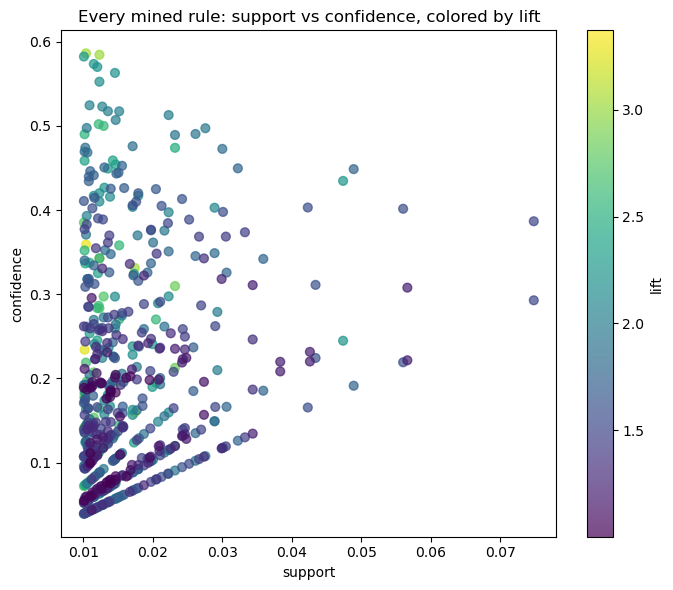

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="viridis", s=40, alpha=0.7)
ax.set_xlabel("support"); ax.set_ylabel("confidence")
fig.colorbar(scatter, label="lift")
ax.set_title("Every mined rule: support vs confidence, colored by lift")
plt.tight_layout(); plt.show()

> ⚠️ **High confidence alone can be misleading.** A rule "buying X -> buying whole milk"
> might have high confidence simply because almost EVERYONE buys whole milk (it's the most
> common item in this dataset) — not because X specifically drives milk purchases. **Lift**
> corrects for this by comparing against milk's overall baseline rate. Always check lift,
> not confidence alone, before trusting a rule as a genuine relationship.

In [8]:
# The single strongest rule by lift, made concrete
top_rule = rules.iloc[0]
print(f"Rule: {set(top_rule['antecedents'])} -> {set(top_rule['consequents'])}")
print(f"Support: {top_rule['support']:.4f}  (appear together in {top_rule['support']:.1%} of all transactions)")
print(f"Confidence: {top_rule['confidence']:.4f}  (given the antecedent, {top_rule['confidence']:.1%} also buy the consequent)")
print(f"Lift: {top_rule['lift']:.2f}  ({top_rule['lift']:.2f}x more likely than the consequent's baseline rate)")

Rule: {'yogurt', 'whole milk'} -> {'curd'}
Support: 0.0101  (appear together in 1.0% of all transactions)
Confidence: 0.1797  (given the antecedent, 18.0% also buy the consequent)
Lift: 3.37  (3.37x more likely than the consequent's baseline rate)


## 🧪 Practice Exercises

**1.** Lower `min_support` from `0.01` to `0.005`. How many more frequent itemsets are
found, and how does FP-Growth's runtime change?

**2.** Filter `rules` to only rules with `confidence > 0.5`, sorted by `lift`. Do these
look like more "obviously true" or more "surprising" associations than the top-lift list
above?

**3.** Pick any 2 items from the top-20 chart in section 0. Compute their lift manually:
`P(both) / (P(item1) * P(item2))`, using simple counting over `transactions`, and confirm
it roughly matches what `association_rules` reports (if that exact pair appears in `rules`).

In [ ]:
# --- Exercise 1 ---
t0 = time.time()
lower_support_itemsets = fpgrowth(basket_df, min_support=0.005, use_colnames=True)
print(f"min_support=0.01:  {len(frequent_itemsets_fpgrowth)} itemsets")
print(f"min_support=0.005: {len(lower_support_itemsets)} itemsets, found in {time.time()-t0:.3f}s")

In [ ]:
# --- Exercise 2 ---
high_confidence_rules = rules[rules["confidence"] > 0.5].sort_values("lift", ascending=False)
high_confidence_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

In [ ]:
# --- Exercise 3 ---
n = len(transactions)
item_a, item_b = "yogurt", "whole milk"
p_a = sum(1 for t in transactions if item_a in t) / n
p_b = sum(1 for t in transactions if item_b in t) / n
p_both = sum(1 for t in transactions if item_a in t and item_b in t) / n
manual_lift = p_both / (p_a * p_b) if p_a * p_b > 0 else float("nan")
print(f"manual lift({item_a} -> {item_b}): {manual_lift:.3f}")

matching_rule = rules[(rules['antecedents'] == frozenset({item_a})) & (rules['consequents'] == frozenset({item_b}))]
if len(matching_rule):
    print(f"mlxtend's reported lift: {matching_rule['lift'].values[0]:.3f}")
else:
    print("(that exact directional rule wasn't among the mined rules at this min_support/min_threshold)")

---
### ✅ Checkpoint — Section 6.4 complete!
You should now be able to:
- Encode raw transactions into the one-hot basket format both algorithms need
- Explain the apriori principle and why it lets Apriori prune the search space
- Explain why FP-Growth avoids Apriori's candidate-generation cost
- Compute support, confidence, and lift, and explain why lift matters more than confidence
  alone

**Next section:** `05-recommendation-systems` — using patterns like these (plus explicit
ratings) to recommend items to a specific user, not just find general associations.